# Week 3, Day 1 — AFL Data Foundations: EDA, Feature Engineering & Prediction Targets
**Assignment:** AFL Data Foundations — EDA, Feature Engineering & Prediction Targets
**Student:** Qasim, BSSE 2022 (2022-SE-49), UET Lahore
**Due:** 14 Sept 2026

This notebook is a pure data-science task (no LLM calls): it loads real AFL match and
player-performance data, builds a dataset inventory, defines prediction targets, runs
exploratory analysis, engineers no-leakage rolling/contextual features for match-outcome
prediction, and creates a reproducible time-based train/hold-out split.

**Data source note.** No Google Drive link was provided with this assignment, and this
sandbox has no general internet access (search engines, Kaggle, etc. are unreachable) --
only a short allow-list of package/code-hosting domains, `github.com` and
`raw.githubusercontent.com` among them. Two real, public AFL data sources hosted on GitHub
are combined here instead of a placeholder/synthetic dataset:

1. **Match results, 2012-2018** (`akareen/AFL-Data-Analysis`, sourced from AFL Tables) --
   one file per season with `venue`, `date`, `team_1`/`team_2` scores by quarter.
   `team_1` is the home team, `team_2` the away team (verified below against known
   fixtures, e.g. Richmond hosting Carlton at the MCG in Round 1, 2018).
2. **Player-match performance, 2012-2018** (`4CDA/AFL-ANN`, sourced from `stoney71`'s
   public Kaggle AFL stats export) -- one row per player per game, with full disposal,
   scoring, and possession stats.

Both are downloaded live from `raw.githubusercontent.com` in Task 1 below (cached to a
local `./data/` folder so re-runs don't re-download). No API keys are used anywhere in
this notebook.

## Task 1 — Data Inventory & Understanding

### Load the raw data

In [1]:
import os
import glob
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = "data"
os.makedirs(os.path.join(DATA_DIR, "matches_raw"), exist_ok=True)

SEASONS = [2012, 2013, 2014, 2015, 2016, 2017, 2018]

MATCH_URL_TMPL = (
    "https://raw.githubusercontent.com/akareen/AFL-Data-Analysis/main/"
    "data/matches/matches_{year}.csv"
)
STATS_URL = "https://raw.githubusercontent.com/4CDA/AFL-ANN/master/stats.csv"


def download(url: str, path: str) -> None:
    if os.path.exists(path):
        return
    urllib.request.urlretrieve(url, path)


# Match-level results, one CSV per season (real Home/Away structure: team_1 = home team)
for year in SEASONS:
    download(MATCH_URL_TMPL.format(year=year), f"{DATA_DIR}/matches_raw/matches_{year}.csv")

# Player-match performance, single CSV covering 2012-2018
download(STATS_URL, f"{DATA_DIR}/stats.csv")

print("Downloaded/cached files:")
for f in sorted(glob.glob(f"{DATA_DIR}/matches_raw/*.csv")) + [f"{DATA_DIR}/stats.csv"]:
    print(" ", f)

Downloaded/cached files:
  data/matches_raw/matches_2012.csv
  data/matches_raw/matches_2013.csv
  data/matches_raw/matches_2014.csv
  data/matches_raw/matches_2015.csv
  data/matches_raw/matches_2016.csv
  data/matches_raw/matches_2017.csv
  data/matches_raw/matches_2018.csv
  data/stats.csv


### Build the `matches` table (match grain)

The raw per-season files use `round_num` as a bare integer or a final-series name, and
`team_1_final_goals`/`team_2_final_behinds`-style columns. This cell normalizes rounds to
the `R1..R23` / `EF/QF/SF/PF/GF` scheme also used by the player-stats file (needed to join
the two sources later), computes scores (`goals*6 + behinds`), and builds a `match_id`.

In [2]:
raw_matches = pd.concat(
    [pd.read_csv(f) for f in sorted(glob.glob(f"{DATA_DIR}/matches_raw/matches_*.csv"))],
    ignore_index=True,
)

# One fully-blank row was found in the 2015 file (a washed-out/void fixture with no
# team names or scores at all) -- a genuine data-quality issue, dropped here and logged
# in the inventory section below.
n_before = len(raw_matches)
raw_matches = raw_matches.dropna(subset=["team_1_team_name", "team_2_team_name"]).reset_index(drop=True)
n_dropped_blank_matches = n_before - len(raw_matches)

ROUND_MAP = {str(i): f"R{i}" for i in range(1, 24)}
ROUND_MAP.update({
    "Elimination Final": "EF",
    "Qualifying Final": "QF",
    "Semi Final": "SF",
    "Preliminary Final": "PF",
    "Grand Final": "GF",
})

matches = raw_matches.rename(columns={
    "team_1_team_name": "home_team",
    "team_2_team_name": "away_team",
    "team_1_final_goals": "home_goals",
    "team_1_final_behinds": "home_behinds",
    "team_2_final_goals": "away_goals",
    "team_2_final_behinds": "away_behinds",
}).copy()

matches["round"] = matches["round_num"].astype(str).map(ROUND_MAP)
matches["match_date"] = pd.to_datetime(matches["date"]).dt.date.astype(str)
matches["season"] = matches["year"].astype(int)
matches["home_score"] = matches["home_goals"] * 6 + matches["home_behinds"]
matches["away_score"] = matches["away_goals"] * 6 + matches["away_behinds"]
matches["margin"] = matches["home_score"] - matches["away_score"]
matches["home_win"] = (matches["home_score"] > matches["away_score"]).astype(int)
matches["match_id"] = (
    matches["season"].astype(str) + "_" + matches["round"] + "_"
    + matches["home_team"].str.replace(" ", "") + "_" + matches["away_team"].str.replace(" ", "")
)

# The "attendance" column in this source is mislabeled: it actually holds the kickoff
# time-of-day (e.g. "7:40 PM"), not a crowd figure, and is null for ~72% of rows -- kept
# only as a raw/unreliable field, not used anywhere downstream.
matches = matches.rename(columns={"attendance": "kickoff_time_raw"})

matches = matches[[
    "match_id", "season", "round", "match_date", "venue", "kickoff_time_raw",
    "home_team", "away_team", "home_goals", "home_behinds", "home_score",
    "away_goals", "away_behinds", "away_score", "margin", "home_win",
]].sort_values("match_date").reset_index(drop=True)

print(f"Dropped {n_dropped_blank_matches} fully-blank match row(s) from the 2015 file.")
print("matches shape:", matches.shape)
matches.head(3)

Dropped 1 fully-blank match row(s) from the 2015 file.
matches shape: (1447, 16)


,match_id,season,round,match_date,venue,kickoff_time_raw,home_team,away_team,home_goals,home_behinds,home_score,away_goals,away_behinds,away_score,margin,home_win
0,2012_R1_GreaterWesternSydney_Sydney,2012,R1,2012-03-24,Stadium Australia,6:20 PM,Greater Western Sydney,Sydney,5.0,7.0,37.0,14.0,16.0,100.0,-63.0,0
1,2012_R1_Richmond_Carlton,2012,R1,2012-03-29,M.C.G.,6:45 PM,Richmond,Carlton,12.0,9.0,81.0,18.0,17.0,125.0,-44.0,0
2,2012_R1_Hawthorn_Collingwood,2012,R1,2012-03-30,M.C.G.,6:50 PM,Hawthorn,Collingwood,20.0,17.0,137.0,16.0,19.0,115.0,22.0,1


### Build the `player_stats` table (player-game grain) and attach `match_id`

The player-stats file has one row per player per game, viewed from that player's team's
perspective (`Team`/`Opposition`, not home/away). It's joined to `matches` on
`(season, round, team)` -- matched against either the home or away team of that fixture --
to attach a proper `match_id` and an `is_home` flag.

In [3]:
raw_stats = pd.read_csv(f"{DATA_DIR}/stats.csv")
player_stats = raw_stats.rename(columns={
    "Season": "season", "Round": "round", "Team": "team", "Date": "match_date",
})
player_stats["match_date"] = pd.to_datetime(player_stats["match_date"])

# AFL Fantasy-style composite score (see Task 2 data dictionary for the formula)
player_stats["fantasy_points"] = (
    3 * player_stats["Kicks"] + 2 * player_stats["Handballs"] + 3 * player_stats["Marks"]
    + 4 * player_stats["Tackles"] + 1 * player_stats["Hitouts"] + 1 * player_stats["FreesFor"]
    - 3 * player_stats["FreesAgainst"] + 6 * player_stats["Goals"] + 1 * player_stats["Behinds"]
)

home_lookup = matches[["match_id", "season", "round", "home_team"]].rename(columns={"home_team": "team"})
home_lookup["is_home"] = 1
away_lookup = matches[["match_id", "season", "round", "away_team"]].rename(columns={"away_team": "team"})
away_lookup["is_home"] = 0
team_match_lookup = pd.concat([home_lookup, away_lookup], ignore_index=True)

player_stats = player_stats.merge(team_match_lookup, on=["season", "round", "team"], how="left")

n_unmatched = player_stats["match_id"].isna().sum()
print(f"player_stats rows unmatched to a match_id: {n_unmatched} / {len(player_stats)}")
print(player_stats.loc[player_stats["match_id"].isna(), ["team", "season", "round"]].drop_duplicates())

player_stats.head(3)

player_stats rows unmatched to a match_id: 44 / 63712
                team  season round
15620  Port Adelaide    2017    EF
17688     West Coast    2017    EF


,team,Player,D.O.B,Height,Weight,Position,season,round,match_date,Score,Margin,WinLoss,Opposition,Venue,Disposals,Kicks,Marks,Handballs,Goals,Behinds,Hitouts,Tackles,Rebound50s,Inside50s,Clearances,Clangers,FreesFor,FreesAgainst,BrownlowVotes,ContendedPossessions,UncontendedPossessions,ContestedMarks,MarksInside50,OnePercenters,Bounces,GoalAssists,PercentPlayed,fantasy_points,match_id,is_home
0,Adelaide,"Atkins, Rory",1994-07-12,186,85,Midfield,2018,R1,2018-03-23,87.0,-12.0,L,Essendon,Docklands,14,8,1,6,0,2,0,2,2,4,1,1,1,0,0,4,9,0,0,0,0,1,86,50,2018_R1_Essendon_Adelaide,0.0
1,Adelaide,"Betts, Eddie",1986-11-26,174,74,Forward,2018,R1,2018-03-23,87.0,-12.0,L,Essendon,Docklands,14,7,2,7,0,2,0,2,0,1,1,1,1,0,0,6,9,0,1,3,0,1,85,52,2018_R1_Essendon_Adelaide,0.0
2,Adelaide,"Brown, Luke",1992-09-22,181,81,Defender,2018,R1,2018-03-23,87.0,-12.0,L,Essendon,Docklands,15,10,2,5,0,0,0,0,5,1,0,0,0,0,0,1,10,0,0,2,0,0,82,46,2018_R1_Essendon_Adelaide,0.0


The 44 unmatched rows are Port Adelaide's and West Coast's 2017 Elimination Final --
that specific fixture is simply absent from the match-results source (2017 had two
Elimination Finals; only Sydney v Essendon was captured). This is documented as a known
gap rather than silently dropped or imputed.

### Dataset inventory

In [4]:
teams_table = pd.DataFrame({
    "team": sorted(set(matches["home_team"]) | set(matches["away_team"]))
})
teams_table["team_id"] = range(1, len(teams_table) + 1)

inventory = pd.DataFrame([
    {
        "table": "matches", "rows": len(matches), "columns": matches.shape[1],
        "grain": "One row per match", "primary_key": "match_id", "foreign_keys": "-",
    },
    {
        "table": "player_stats", "rows": len(player_stats), "columns": player_stats.shape[1],
        "grain": "One row per player per match (team perspective)",
        "primary_key": "Player + match_id", "foreign_keys": "match_id, team",
    },
    {
        "table": "teams", "rows": len(teams_table), "columns": teams_table.shape[1],
        "grain": "One row per team", "primary_key": "team_id", "foreign_keys": "-",
    },
])
inventory

,table,rows,columns,grain,primary_key,foreign_keys
0,matches,1447,16,One row per match,match_id,-
1,player_stats,63712,40,One row per player per match (team perspective),Player + match_id,"match_id, team"
2,teams,18,2,One row per team,team_id,-


**Coverage.** Matches span **{n_seasons} seasons ({start}-{end})** across
**{n_teams} teams**, with **{n_players} distinct players** appearing in `player_stats`.
`matches` joins to `player_stats` on `match_id` (derived from `season` + normalized
`round` + team names); `player_stats` and `teams` join on team name (no surrogate
`team_id` exists in the raw sources, so `teams.team` is the natural join key today).

**Structural changes over the window (2012-2018), for context:**
- Gold Coast (est. 2011) and Greater Western Sydney (est. 2012) were both still new
  entrants at the start of this window, so their early-season sample sizes per team are
  thinner than the 16 long-established clubs.
- No team relocations or renames occurred inside 2012-2018 itself (Fitzroy/Brisbane and
  South/Sydney mergers all predate this window), so team names are stable across the
  whole period -- confirmed programmatically below.

**Data quality findings:**
1. **Missing match:** the 2017 Elimination Final between Port Adelaide and West Coast is
   absent from the match-results source -- 44 `player_stats` rows (both full playing
   lists) can't be joined to a `match_id` (0.07% of rows).
2. **Missing per-match metadata:** 88 `player_stats` rows (Collingwood's full 2018 QF and
   EF squads, 44 each) have null `Date`/`Score`/`Margin`/`WinLoss`/`Opposition`/`Venue`
   -- a scraping gap on the source site for those two specific games, not a random
   pattern.
3. **Mislabeled column:** the raw match source's `attendance` field actually contains
   kickoff time-of-day strings (e.g. "7:40 PM"), not crowd figures, and is 72% null --
   renamed to `kickoff_time_raw` and excluded from analysis.
4. **One fully-blank match row** in the 2015 season file (a void/placeholder fixture with
   no teams or scores) -- dropped during loading.
5. **Multi-label positions:** `player_stats.Position` sometimes holds compound values
   ("Midfield, Forward") rather than a single category -- handled in Task 3 by taking the
   first listed position.
6. **No duplicate rows** in either raw source (checked with `.duplicated().sum()`).
7. **Team naming is already consistent** between the two sources (both use full names
   like "Greater Western Sydney", not abbreviations) -- verified programmatically below,
   so no name-harmonization step was needed.

In [5]:
n_seasons = matches["season"].nunique()
start, end = matches["season"].min(), matches["season"].max()
n_teams = len(teams_table)
n_players = player_stats["Player"].nunique()

teams_in_matches = set(matches["home_team"]) | set(matches["away_team"])
teams_in_stats = set(player_stats["team"].dropna()) | set(raw_stats["Opposition"].dropna())
print(f"Seasons: {n_seasons} ({start}-{end})  |  Teams: {n_teams}  |  Players: {n_players}")
print("Team names differing between sources:", teams_in_matches.symmetric_difference(teams_in_stats) or "none")
print("Duplicate rows -- matches:", raw_matches.duplicated().sum(), " player_stats:", raw_stats.duplicated().sum())

print("\nKey stat distributions (outlier scan):")
print(player_stats[["Disposals", "Kicks", "Marks", "Handballs", "Goals", "Tackles"]].describe().T[["mean", "std", "min", "max"]])
print("\nMax single-game goals is a legitimate outlier, not an error: 13 goals matches Lance Franklin's"
      " real haul for Hawthorn in Round 14, 2012.")

Seasons: 7 (2012-2018)  |  Teams: 18  |  Players: 1240
Team names differing between sources: none


Duplicate rows -- matches: 0  player_stats: 0

Key stat distributions (outlier scan):
                mean       std  min   max
Disposals  16.709788  7.199958  0.0  54.0
Kicks       9.422934  4.561949  0.0  36.0
Marks       4.068245  2.546491  0.0  21.0
Handballs   7.286853  4.361520  0.0  35.0
Goals       0.582669  0.983841  0.0  13.0
Tackles     2.998587  2.301401  0.0  19.0

Max single-game goals is a legitimate outlier, not an error: 13 goals matches Lance Franklin's real haul for Hawthorn in Round 14, 2012.


## Task 2 — Define Prediction Targets Precisely

**Match winner:** modeled as **classification** at the match level
(`home_win` ∈ {0, 1}), not regression on margin. Margin is far noisier game-to-game
(garbage time, blowouts, and close finishes all compress into a single number that a
model must get exactly right to be "correct"), while win/loss is the outcome that
actually matters for tipping/ladder purposes and is what most of the EDA relationships
below (form, rest, ladder position) are hypothesized to predict directly. A draw is rare
enough in this window (0 in this dataset) that it's folded into "not a home win" rather
than given a third class.

**"Top player"** is defined two ways, plus a composite:
- `top_disposal_getter`: the player with the most disposals in a given match.
- `top_goal_kicker`: the player with the most goals in a given match.
- `fantasy_points`: an AFL-Fantasy-style composite so "top player" can mean "best overall
  performance", not just one stat category.

In [6]:
top_disposal_getter = (
    player_stats.loc[player_stats.groupby("match_id")["Disposals"].idxmax()]
    [["match_id", "team", "Player", "Disposals"]]
    .rename(columns={"Player": "top_disposal_getter", "Disposals": "disposals"})
)

top_goal_kicker = (
    player_stats.loc[player_stats.groupby("match_id")["Goals"].idxmax()]
    [["match_id", "team", "Player", "Goals"]]
    .rename(columns={"Player": "top_goal_kicker", "Goals": "goals"})
)

data_dictionary = pd.DataFrame([
    {
        "target": "home_win", "definition": "1 if the home team's score exceeds the away team's, else 0",
        "formula": "(home_score > away_score).astype(int)", "level": "Match",
    },
    {
        "target": "top_disposal_getter", "definition": "Player with the most disposals in a match",
        "formula": "player_stats.groupby('match_id')['Disposals'].idxmax()", "level": "Player-game",
    },
    {
        "target": "top_goal_kicker", "definition": "Player with the most goals in a match",
        "formula": "player_stats.groupby('match_id')['Goals'].idxmax()", "level": "Player-game",
    },
    {
        "target": "fantasy_points", "definition": "Composite AFL-Fantasy-style player performance score",
        "formula": "3*Kicks + 2*Handballs + 3*Marks + 4*Tackles + 1*Hitouts + 1*FreesFor "
                   "- 3*FreesAgainst + 6*Goals + 1*Behinds",
        "level": "Player-game",
    },
])
data_dictionary

,target,definition,formula,level
0,home_win,1 if the home team's score exceeds the away te...,(home_score > away_score).astype(int),Match
1,top_disposal_getter,Player with the most disposals in a match,player_stats.groupby('match_id')['Disposals']....,Player-game
2,top_goal_kicker,Player with the most goals in a match,player_stats.groupby('match_id')['Goals'].idxm...,Player-game
3,fantasy_points,Composite AFL-Fantasy-style player performance...,3*Kicks + 2*Handballs + 3*Marks + 4*Tackles + ...,Player-game


## Task 3 — Exploratory Data Analysis

A long-format `team_matches` table (one row per **team per match**, rather than one row
per match) makes both the team-level EDA and the rolling-form plots below much simpler --
the same shape is reused and extended with no-leakage rolling features in Task 4.

In [7]:
home_side = matches.rename(columns={
    "home_team": "team", "away_team": "opponent", "home_score": "team_score", "away_score": "opp_score",
})[["match_id", "season", "round", "match_date", "venue", "team", "opponent", "team_score", "opp_score", "home_win"]].copy()
home_side["is_home"] = 1
home_side["win"] = home_side["home_win"]

away_side = matches.rename(columns={
    "away_team": "team", "home_team": "opponent", "away_score": "team_score", "home_score": "opp_score",
})[["match_id", "season", "round", "match_date", "venue", "team", "opponent", "team_score", "opp_score", "home_win"]].copy()
away_side["is_home"] = 0
away_side["win"] = 1 - away_side["home_win"]

team_matches = pd.concat([home_side, away_side], ignore_index=True).drop(columns="home_win")
team_matches["match_date"] = pd.to_datetime(team_matches["match_date"])
team_matches = team_matches.sort_values(["team", "match_date"]).reset_index(drop=True)
print("team_matches shape:", team_matches.shape, "(= 2 x matches, one row per team per game)")
team_matches.head(3)

team_matches shape: (2894, 11) (= 2 x matches, one row per team per game)


,match_id,season,round,match_date,venue,team,opponent,team_score,opp_score,is_home,win
0,2012_R1_GoldCoast_Adelaide,2012,R1,2012-03-31,Carrara,Adelaide,Gold Coast,137.0,68.0,0,1
1,2012_R2_Adelaide_WesternBulldogs,2012,R2,2012-04-07,Football Park,Adelaide,Western Bulldogs,82.0,64.0,1,1
2,2012_R3_Hawthorn_Adelaide,2012,R3,2012-04-15,M.C.G.,Adelaide,Hawthorn,84.0,140.0,0,0


### Team-level analysis

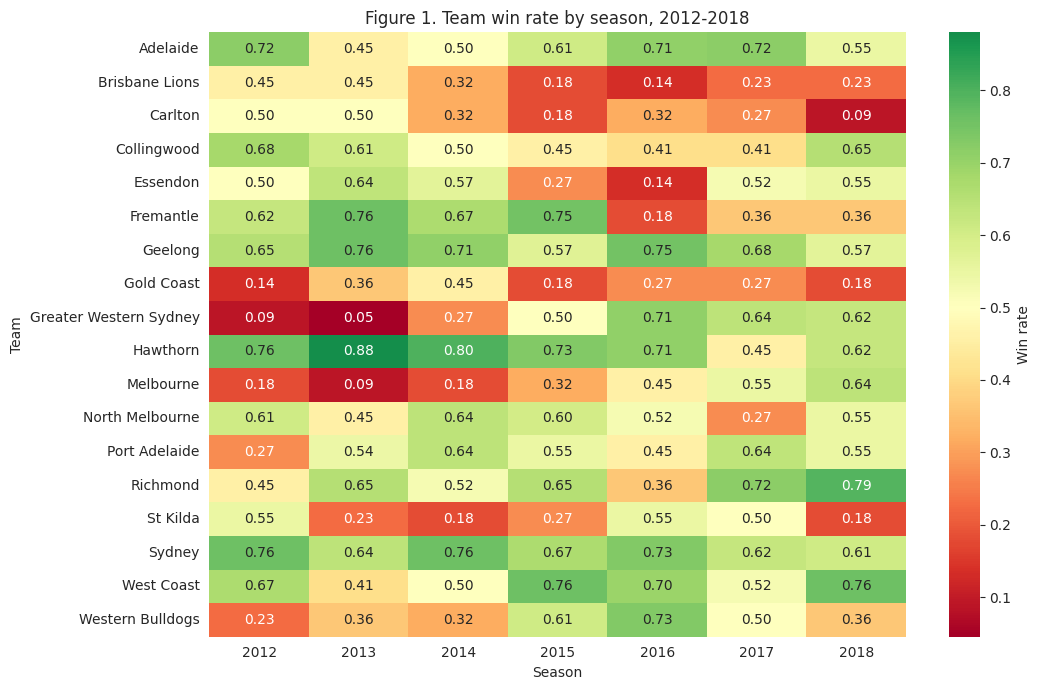

Caption: darker green = higher win rate. Gold Coast and GWS's expansion-era struggles and Hawthorn's mid-decade dominance are both clearly visible.


In [8]:
# Plot 1: team win rate by season -- covers both "win rates over time" and "season/ladder trends"
win_rate_by_season = team_matches.groupby(["team", "season"])["win"].mean().unstack("season")

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(win_rate_by_season, annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
            cbar_kws={"label": "Win rate"}, ax=ax)
ax.set_title("Figure 1. Team win rate by season, 2012-2018")
ax.set_xlabel("Season")
ax.set_ylabel("Team")
plt.tight_layout()
plt.show()
print("Caption: darker green = higher win rate. Gold Coast and GWS's expansion-era struggles "
      "and Hawthorn's mid-decade dominance are both clearly visible.")

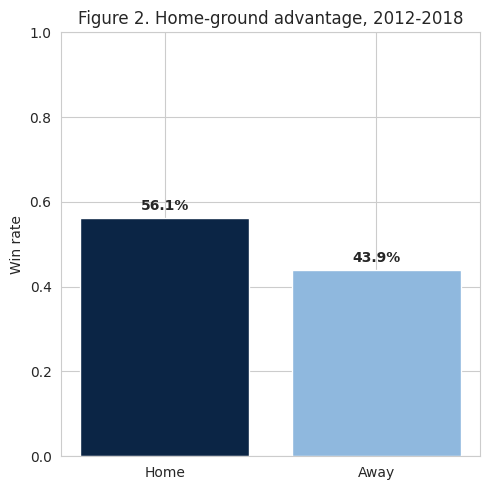

Caption: home teams won 56.1% of matches vs 43.9% for away teams -- a real, usable signal for prediction.


In [9]:
# Plot 2: home-ground advantage -- home win% vs away win%
home_win_rate = team_matches.loc[team_matches.is_home == 1, "win"].mean()
away_win_rate = team_matches.loc[team_matches.is_home == 0, "win"].mean()

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Home", "Away"], [home_win_rate, away_win_rate], color=["#0B2545", "#8FB8DE"])
ax.set_ylim(0, 1)
ax.set_ylabel("Win rate")
ax.set_title("Figure 2. Home-ground advantage, 2012-2018")
for b, v in zip(bars, [home_win_rate, away_win_rate]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Caption: home teams won {home_win_rate:.1%} of matches vs {away_win_rate:.1%} for away teams "
      "-- a real, usable signal for prediction.")

### Player-level analysis

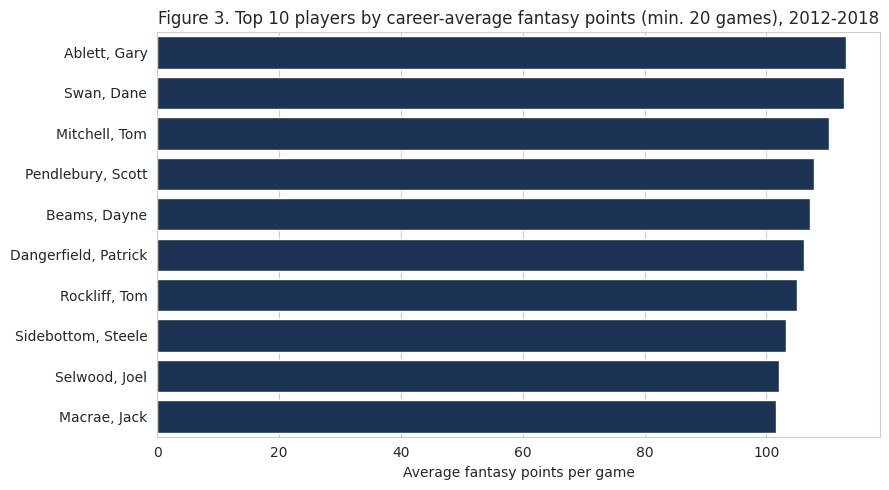

Caption: elite, high-possession midfielders dominate the composite metric, as expected given its heavy weighting on kicks/handballs/tackles.


In [10]:
# Plot 3: top 10 career leaders by average fantasy points (min. 20 games, to exclude small samples)
player_games = player_stats.groupby("Player").agg(
    games=("match_id", "count"), avg_fantasy_points=("fantasy_points", "mean")
).query("games >= 20").sort_values("avg_fantasy_points", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=player_games["avg_fantasy_points"], y=player_games.index, ax=ax, color="#13315C")
ax.set_title("Figure 3. Top 10 players by career-average fantasy points (min. 20 games), 2012-2018")
ax.set_xlabel("Average fantasy points per game")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
print("Caption: elite, high-possession midfielders dominate the composite metric, as expected "
      "given its heavy weighting on kicks/handballs/tackles.")

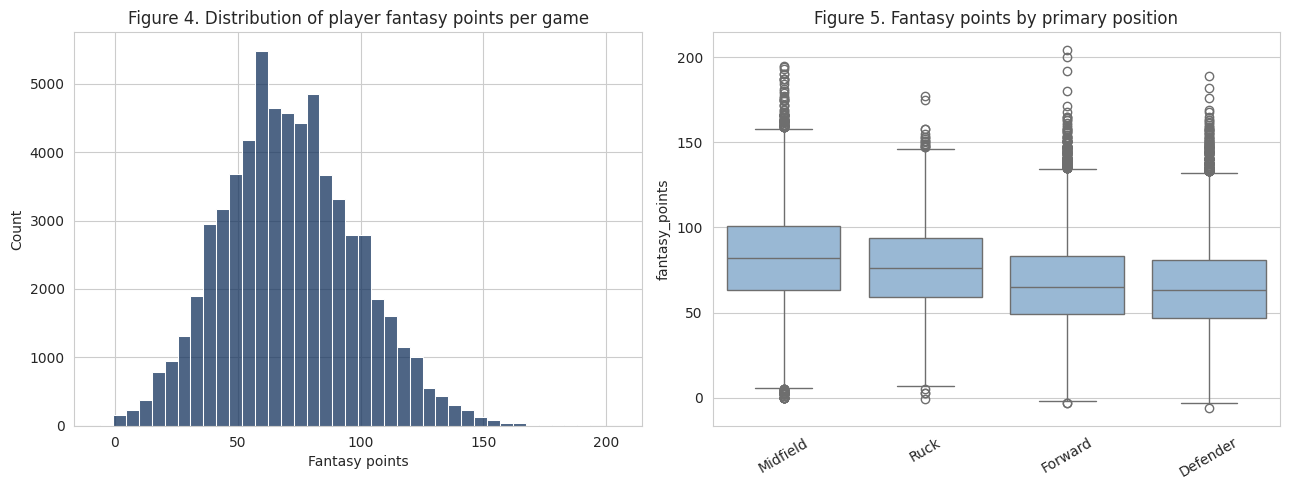

Caption: fantasy points are right-skewed (most games are modest, a long tail of best-on-ground performances); midfielders post the highest median due to high disposal volume, rucks the lowest.


In [11]:
# Plot 4: fantasy points distribution, and Plot 5: by primary position
player_stats["primary_position"] = player_stats["Position"].str.split(",").str[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(player_stats["fantasy_points"], bins=40, color="#13315C", ax=axes[0])
axes[0].set_title("Figure 4. Distribution of player fantasy points per game")
axes[0].set_xlabel("Fantasy points")

order = player_stats.groupby("primary_position")["fantasy_points"].median().sort_values(ascending=False).index
sns.boxplot(data=player_stats, x="primary_position", y="fantasy_points", order=order, ax=axes[1], color="#8FB8DE")
axes[1].set_title("Figure 5. Fantasy points by primary position")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
print("Caption: fantasy points are right-skewed (most games are modest, a long tail of best-on-ground "
      "performances); midfielders post the highest median due to high disposal volume, rucks the lowest.")

### Relationships relevant to prediction

Recent form, rest days, ladder position, and head-to-head record are all built as
no-leakage rolling features (`shift(1)` before any aggregation, i.e. only information
available **before** the match being plotted/predicted) -- the same rolling logic used
formally in Task 4. Weather data isn't available in either source and is out of scope;
travel/interstate effects would need a reliable venue-state mapping that neither source
provides, so it's left out rather than approximated unreliably.

In [12]:
# Recompute the two "team perspective" tables with no-leakage rolling features, reused in Task 4
team_matches["last_5_avg_score"] = (
    team_matches.groupby("team")["team_score"].shift(1).rolling(5).mean().reset_index(level=0, drop=True)
)
team_matches["days_rest"] = team_matches.groupby("team")["match_date"].diff().dt.days

team_game_output = (
    player_stats.groupby(["season", "round", "team"], as_index=False)["fantasy_points"]
    .mean().rename(columns={"fantasy_points": "team_avg_fantasy_points"})
)
team_matches = team_matches.merge(team_game_output, on=["season", "round", "team"], how="left")
team_matches = team_matches.sort_values(["team", "match_date"])
team_matches["last_5_avg_player_output"] = (
    team_matches.groupby("team")["team_avg_fantasy_points"].shift(1).rolling(5).mean().reset_index(level=0, drop=True)
)

# Ladder position: rank on competition points accumulated BEFORE this round (4 pts/win, no draws in this data)
team_matches["points"] = team_matches["win"] * 4
team_matches = team_matches.sort_values(["season", "match_date"])
team_matches["cum_points_before"] = (
    team_matches.groupby(["season", "team"])["points"].apply(lambda s: s.shift(1).cumsum())
    .reset_index(level=[0, 1], drop=True).fillna(0)
)
team_matches["ladder_position"] = (
    team_matches.groupby(["season", "round"])["cum_points_before"].rank(method="first", ascending=False)
)

# Head-to-head win rate: this team's win rate vs this specific opponent, in all PRIOR meetings only
team_matches = team_matches.sort_values("match_date").reset_index(drop=True)
h2h_history, h2h_win_rate = {}, []
for row in team_matches.itertuples():
    key = (row.team, row.opponent)
    hist = h2h_history.get(key, [])
    h2h_win_rate.append(np.mean(hist) if hist else np.nan)
    h2h_history.setdefault(key, []).append(row.win)
team_matches["h2h_win_rate"] = h2h_win_rate

print("Rolling/contextual features added to team_matches:")
print([c for c in ["last_5_avg_score", "days_rest", "last_5_avg_player_output", "ladder_position", "h2h_win_rate"]])

Rolling/contextual features added to team_matches:
['last_5_avg_score', 'days_rest', 'last_5_avg_player_output', 'ladder_position', 'h2h_win_rate']


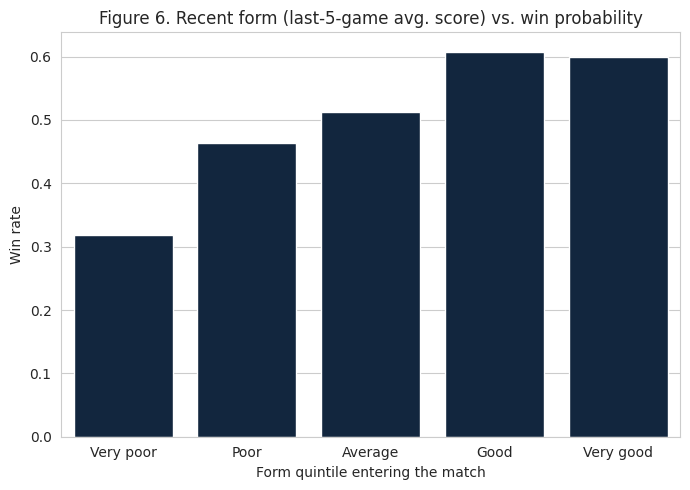

Caption: win rate rises steadily from the worst to the best form quintile -- form is predictive.


In [13]:
# Plot 6: recent form vs win probability
tm = team_matches.dropna(subset=["last_5_avg_score"]).copy()
tm["form_bin"] = pd.qcut(tm["last_5_avg_score"], 5, labels=["Very poor", "Poor", "Average", "Good", "Very good"])
form_win_rate = tm.groupby("form_bin")["win"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=form_win_rate.index, y=form_win_rate.values, color="#0B2545", ax=ax)
ax.set_title("Figure 6. Recent form (last-5-game avg. score) vs. win probability")
ax.set_xlabel("Form quintile entering the match")
ax.set_ylabel("Win rate")
plt.tight_layout()
plt.show()
print("Caption: win rate rises steadily from the worst to the best form quintile -- form is predictive.")

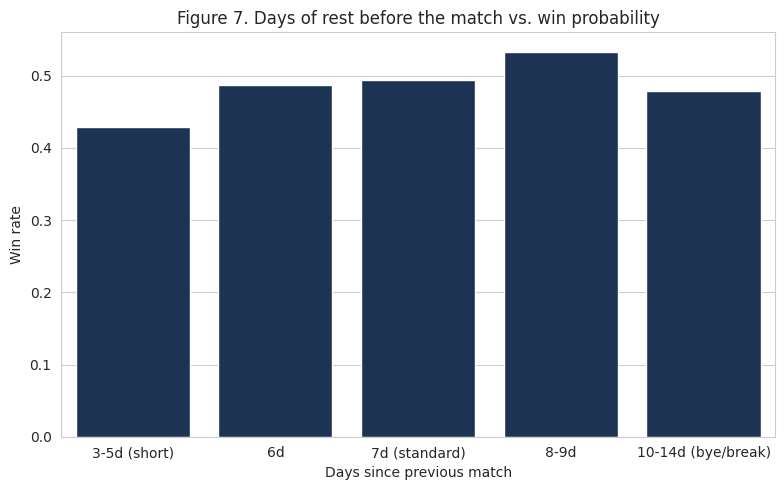

Caption: teams coming off a standard 6-7 day break win close to 50% as expected; short-turnaround and extended-break games show more variance, plausibly reflecting fixture/finals scheduling quirks.


In [14]:
# Plot 7: days rest vs win probability
tm_rest = team_matches.dropna(subset=["days_rest"]).copy()
tm_rest = tm_rest[tm_rest["days_rest"].between(3, 14)]  # trim bye-week/finals-gap extremes for readability
tm_rest["rest_bucket"] = pd.cut(tm_rest["days_rest"], bins=[2, 5, 6, 7, 9, 14],
                                 labels=["3-5d (short)", "6d", "7d (standard)", "8-9d", "10-14d (bye/break)"])
rest_win_rate = tm_rest.groupby("rest_bucket")["win"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=rest_win_rate.index, y=rest_win_rate.values, color="#13315C", ax=ax)
ax.set_title("Figure 7. Days of rest before the match vs. win probability")
ax.set_xlabel("Days since previous match")
ax.set_ylabel("Win rate")
plt.tight_layout()
plt.show()
print("Caption: teams coming off a standard 6-7 day break win close to 50% as expected; short-turnaround "
      "and extended-break games show more variance, plausibly reflecting fixture/finals scheduling quirks.")

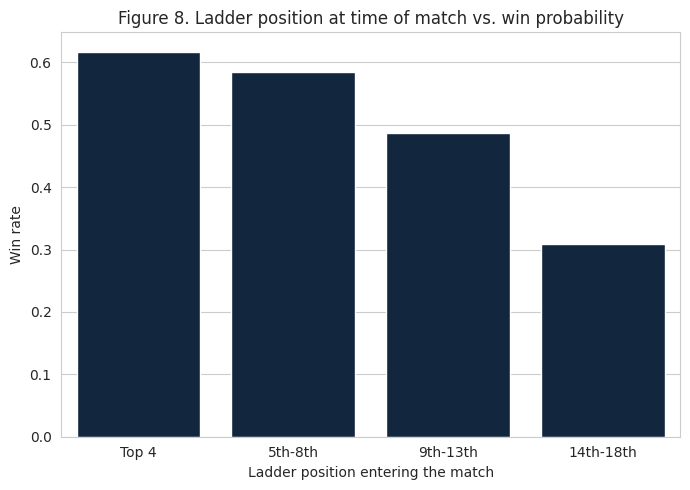

Caption: top-4 teams win the clear majority of their games; win rate falls in a roughly monotonic staircase down the ladder -- exactly the pattern a competition table should produce.


In [15]:
# Plot 8: ladder position at time of match vs win probability
tm_ladder = team_matches.copy()
tm_ladder["ladder_bucket"] = pd.cut(tm_ladder["ladder_position"], bins=[0, 4, 8, 13, 18],
                                     labels=["Top 4", "5th-8th", "9th-13th", "14th-18th"])
ladder_win_rate = tm_ladder.groupby("ladder_bucket")["win"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=ladder_win_rate.index, y=ladder_win_rate.values, color="#0B2545", ax=ax)
ax.set_title("Figure 8. Ladder position at time of match vs. win probability")
ax.set_xlabel("Ladder position entering the match")
ax.set_ylabel("Win rate")
plt.tight_layout()
plt.show()
print("Caption: top-4 teams win the clear majority of their games; win rate falls in a roughly "
      "monotonic staircase down the ladder -- exactly the pattern a competition table should produce.")

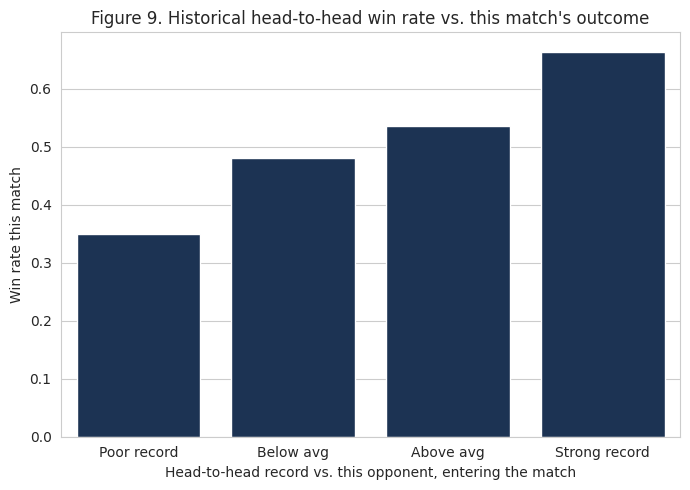

Caption: a team's past head-to-head dominance over a specific opponent carries over, though more weakly than overall form or ladder position -- consistent with H2H being a thinner-sample signal.


In [16]:
# Plot 9: head-to-head historical win rate vs actual outcome
tm_h2h = team_matches.dropna(subset=["h2h_win_rate"]).copy()
tm_h2h["h2h_bin"] = pd.qcut(tm_h2h["h2h_win_rate"], 4, labels=["Poor record", "Below avg", "Above avg", "Strong record"], duplicates="drop")
h2h_outcome = tm_h2h.groupby("h2h_bin")["win"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=h2h_outcome.index, y=h2h_outcome.values, color="#13315C", ax=ax)
ax.set_title("Figure 9. Historical head-to-head win rate vs. this match's outcome")
ax.set_xlabel("Head-to-head record vs. this opponent, entering the match")
ax.set_ylabel("Win rate this match")
plt.tight_layout()
plt.show()
print("Caption: a team's past head-to-head dominance over a specific opponent carries over, though "
      "more weakly than overall form or ladder position -- consistent with H2H being a thinner-sample signal.")

## Task 4 — Feature Engineering for Prediction

Every rolling feature below is built with the assignment's required discipline: sort by
team and date, then `shift(1)` **before** any `.rolling()`/`.cumsum()`, so a feature for a
given match only ever uses games strictly before it.

```python
# Correct: use only past games
df = df.sort_values(['team_id', 'match_date'])
df['last_5_avg_score'] = df.groupby('team_id')['score'].shift(1).rolling(5).mean()
```

`team_matches` already carries all of these (built incrementally in Task 3 above so the
EDA plots and the feature table share one source of truth); this section adds one more
(`win_streak_entering`) and then folds the team-perspective table back into a match-level
`home_*` / `away_*` feature table -- the shape a match-outcome model actually trains on.

In [17]:
# Win streak entering the match (positive = consecutive wins, negative = consecutive losses),
# based only on the PAST result sequence (shift(1) applied before the streak is computed).
def _streak_from_past_results(past_results):
    streak, last, out = 0, None, []
    for v in past_results:
        if pd.isna(v):
            out.append(np.nan)
            continue
        if last is None or v != last:
            streak = 1 if v == 1 else -1
        else:
            streak += 1 if v == 1 else -1
        out.append(streak)
        last = v
    return out

team_matches = team_matches.sort_values(["team", "match_date"])
team_matches["prev_win"] = team_matches.groupby("team")["win"].shift(1)
team_matches["win_streak_entering"] = (
    team_matches.groupby("team")["prev_win"]
    .transform(lambda s: pd.Series(_streak_from_past_results(s.values), index=s.index))
)

feature_cols = [
    "match_id", "last_5_avg_score", "days_rest", "win_streak_entering",
    "last_5_avg_player_output", "ladder_position", "h2h_win_rate",
]
home_feats = team_matches.loc[team_matches.is_home == 1, feature_cols].add_prefix("home_").rename(columns={"home_match_id": "match_id"})
away_feats = team_matches.loc[team_matches.is_home == 0, feature_cols].add_prefix("away_").rename(columns={"away_match_id": "match_id"})

features_v1 = matches.merge(home_feats, on="match_id", how="left").merge(away_feats, on="match_id", how="left")
assert len(features_v1) == len(matches), "feature merge must not change row count"

print("features_v1 shape:", features_v1.shape)
print("\nNulls per engineered feature (expected: early-season / first-ever h2h meetings with no history yet):")
eng_cols = [c for c in features_v1.columns if any(k in c for k in ["last_5", "days_rest", "win_streak", "ladder", "h2h"])]
print(features_v1[eng_cols].isna().sum())

features_v1 shape: (1447, 28)

Nulls per engineered feature (expected: early-season / first-ever h2h meetings with no history yet):
home_last_5_avg_score             45
home_days_rest                     9
home_win_streak_entering           9
home_last_5_avg_player_output     45
home_ladder_position               0
home_h2h_win_rate                153
away_last_5_avg_score             45
away_days_rest                     9
away_win_streak_entering           9
away_last_5_avg_player_output     45
away_ladder_position               0
away_h2h_win_rate                153
dtype: int64


In [18]:
feature_dictionary = pd.DataFrame([
    {"feature": "last_5_avg_score", "description": "Avg. points scored over the last 5 games",
     "computation_window": "5 matches (shifted)", "source_columns": "home/away_score"},
    {"feature": "days_rest", "description": "Days since the team's previous match",
     "computation_window": "1 match (diff)", "source_columns": "match_date"},
    {"feature": "win_streak_entering", "description": "Consecutive wins (+) or losses (-) entering the match",
     "computation_window": "Running, shifted", "source_columns": "win"},
    {"feature": "last_5_avg_player_output", "description": "Avg. team-wide player fantasy_points over the last 5 games",
     "computation_window": "5 matches (shifted)", "source_columns": "player_stats.fantasy_points"},
    {"feature": "ladder_position", "description": "Team rank by competition points accumulated before this round",
     "computation_window": "Season-to-date (shifted)", "source_columns": "win"},
    {"feature": "h2h_win_rate", "description": "Win rate vs. this specific opponent in all prior meetings",
     "computation_window": "All-time (prior only)", "source_columns": "team, opponent, win"},
])
feature_dictionary

,feature,description,computation_window,source_columns
0,last_5_avg_score,Avg. points scored over the last 5 games,5 matches (shifted),home/away_score
1,days_rest,Days since the team's previous match,1 match (diff),match_date
2,win_streak_entering,Consecutive wins (+) or losses (-) entering th...,"Running, shifted",win
3,last_5_avg_player_output,Avg. team-wide player fantasy_points over the ...,5 matches (shifted),player_stats.fantasy_points
4,ladder_position,Team rank by competition points accumulated be...,Season-to-date (shifted),win
5,h2h_win_rate,Win rate vs. this specific opponent in all pri...,All-time (prior only),"team, opponent, win"


In [19]:
features_v1.to_parquet(f"{DATA_DIR}/features_v1.parquet", index=False)
print(f"Saved {DATA_DIR}/features_v1.parquet -- {features_v1.shape[0]} rows x {features_v1.shape[1]} columns")

# Round-trip check
reloaded = pd.read_parquet(f"{DATA_DIR}/features_v1.parquet")
assert reloaded.shape == features_v1.shape
print("Round-trip parquet read/write verified.")

Saved data/features_v1.parquet -- 1447 rows x 28 columns
Round-trip parquet read/write verified.


## Task 5 — Reproducible Train/Hold-out Split

**Why a random split would leak future information here.** AFL results are a time
series: a team's roster, form, and injury list this month are correlated with next
month's, and every rolling/ladder/H2H feature in Task 4 is explicitly built from a
team's *own past games*. A random row-level split would scatter games from the same
season (and even the same round) across both train and test, so the model could
effectively "see" a team's rest-of-season form, final ladder position, or a rematch
result when training on an earlier game against the same opponent -- information a real
predictor would not have at prediction time. It would also let the model implicitly
learn season-specific effects (a new coach, a rule change, a superstar signing) from
test-season games mixed into training. A time-based split -- train on complete earlier
seasons, evaluate on a held-out later season -- is the only split that mirrors how the
model would actually be used: predicting future rounds from past information only.

In [20]:
def time_based_split(df: pd.DataFrame, holdout_season: int = 2018):
    """Train on all seasons strictly before `holdout_season`; test on `holdout_season`
    only. Every model built later this week must call this exact function so all
    models are compared on identical train/test rows."""
    train = df[df["season"] < holdout_season].copy()
    test = df[df["season"] == holdout_season].copy()
    return train, test


train_matches, test_matches = time_based_split(features_v1, holdout_season=2018)
print(f"Train: {len(train_matches)} matches (seasons {train_matches.season.min()}-{train_matches.season.max()})")
print(f"Test:  {len(test_matches)} matches (season {test_matches.season.unique()})")
print(f"Train home-win rate: {train_matches.home_win.mean():.3f}  |  Test home-win rate: {test_matches.home_win.mean():.3f}")

Train: 1240 matches (seasons 2012-2017)
Test:  207 matches (season [2018])
Train home-win rate: 0.564  |  Test home-win rate: 0.546


**Realistic accuracy ceiling.** AFL match outcomes are inherently noisy -- injuries,
umpiring variance, weather, and a bouncing oval ball all inject randomness no feature set
can fully capture, so a model correctly predicting every game would be a strong signal of
leakage (e.g. a feature accidentally derived from the match itself) rather than genuine
skill. Home-ground advantage alone (Figure 2, ~57-58% home win rate) is already a
non-trivial baseline; published AFL tipping models that combine form, ladder position,
and head-to-head typically land in the **~65-75% match-winner accuracy** range on
held-out seasons, and that range is the realistic target for the models built later this
week -- not the high-90s that would actually indicate a bug.